# MongoDB provisioning — initial analysis (n=5)

This notebook looks at the n=5 run (five repeats of each agent × recipe
pair) and decides what to run at larger scale.

We **ran six recipes**. After looking at the results, we will **not**
spend more trials on two of them: naive ephemeral Atlas, and Atlas CLI
to real cloud. More repeats will not change the story (nobody finds
ephemeral clusters without the curl; nobody logs into hosted Atlas).
The four recipes that continue are Docker, ephemeral Atlas with curl,
Atlas CLI local, and apt.

- Experiment: `mongodb-provisioning`
- Primary request: `01M0K02HXMWQWP59QE4DE3NMA4` (30 variants × 5 repeats)
- Retry: `01M0K11JZAPN2N1Y5ZJFFRYYAE` (Cursor × Sonnet × ephemeral-curl, one
  replacement after `model_unsupported_by_harness`)
- n=5 matrix: 6 prompts × 5 extensions × n=5 (150 intended trials)
- **Scale matrix:** 4 prompts × 5 extensions
- Date: 2026-08-21
- Extensions: `claude-sonnet`, `cursor-sonnet`, `cursor-grok`,
  `cursor-terra`, `codex-terra` (no `codex-luna`)
- n=5 prompts: `docker`, `atlas-ephemeral-curl`, `atlas-ephemeral-naive`,
  `atlas-cli-local`, `local-package-manager`, `atlas-cli-cloud`
- Scale prompts: `docker`, `atlas-ephemeral-curl`, `atlas-cli-local`,
  `local-package-manager`

A trial **passes** only when all three tests pass: `uri-reported`,
`connection-verified-in-agent`, and `method-constraint`. For docker /
Atlas CLI local / apt, method-constraint is a documented no-op. For Atlas
cloud and both ephemeral prompts it requires `*.mongodb.net` /
`*.mongodb-dev.net`.

Primary inference is **method-level** at 85% confidence (Wilson for rates;
bootstrap for means). Product MDEs: **10pp** completion, **15%** relative
efficiency. Cell-level tables are descriptive. n=5 cannot confirm a 10pp
gap; pooling across extensions gives ~25 trials per method.

Queries return derived metrics and boolean evidence, not raw URIs or tool
payloads.


Install analysis dependencies into the active kernel (the project `.venv`
if that is selected). Then re-run the next cell.

`ax auth status` should show a signed-in org. Offline alternative:
`ax run download 01M0K02HXMWQWP59QE4DE3NMA4` (and the retry id), then set
`AX_PARQUET_DIR`.


In [1]:
%pip install requests pandas matplotlib numpy python-dotenv


Using project .venv packages (skip %pip on this execute).


In [2]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

%matplotlib inline

EXPERIMENT_ID = "mongodb-provisioning"
RUN_REQUEST_IDS = [
    "01M0K02HXMWQWP59QE4DE3NMA4",
    "01M0K11JZAPN2N1Y5ZJFFRYYAE",
]
REQUEST_SQL = ", ".join(f"'{rid}'" for rid in RUN_REQUEST_IDS)
EXPECTED_TRIALS = 150
AX_API_BASE = os.environ.get("AX_API_BASE", "https://app.514.ax").rstrip("/")
AX_PARQUET_DIR = os.environ.get("AX_PARQUET_DIR", "")
CLI_CREDENTIALS_PATH = Path.home() / ".fiveonefour/axp/credentials.toml"

# Two-sided 85% normal quantile Φ^{-1}(0.925). Tech design uses 85%, not 95%.
Z_85 = 1.4395314709384563
MDE_PP = 0.10
MDE_REL = 0.15
N_BOOT = 4000
RNG = np.random.default_rng(21)

TEST_NAMES = [
    "uri-reported",
    "connection-verified-in-agent",
    "method-constraint",
]
UNAUTH_METHODS = [
    "docker",
    "atlas-ephemeral-curl",
    "atlas-ephemeral-naive",
    "atlas-cli-local",
    "local-package-manager",
]
UNAUTH_NO_NAIVE = [
    "docker",
    "atlas-ephemeral-curl",
    "atlas-cli-local",
    "local-package-manager",
]
# Recipes we will keep running at scale. n=5 still includes the two we drop.
SCALE_METHODS = [
    "docker",
    "atlas-ephemeral-curl",
    "atlas-cli-local",
    "local-package-manager",
]
DROPPED_FROM_SCALE = [
    "atlas-ephemeral-naive",
    "atlas-cli-cloud",
]
CLOUD_BOUND = [
    "atlas-ephemeral-curl",
    "atlas-ephemeral-naive",
    "atlas-cli-cloud",
]
METHOD_ORDER = [
    "docker",
    "atlas-ephemeral-curl",
    "atlas-ephemeral-naive",
    "atlas-cli-local",
    "local-package-manager",
    "atlas-cli-cloud",
]
EXTENSION_ORDER = [
    "claude-sonnet",
    "cursor-sonnet",
    "cursor-grok",
    "cursor-terra",
    "codex-terra",
]
HARNESS_PAIRS = [
    ("claude-sonnet", "cursor-sonnet", "Sonnet across Claude vs Cursor"),
    ("codex-terra", "cursor-terra", "Terra across Codex vs Cursor"),
]
EXTENSION_FROM_AGENT_MODEL = {
    ("claude", "claude-sonnet-5"): "claude-sonnet",
    ("cursor", "claude-sonnet-5"): "cursor-sonnet",
    ("cursor", "grok-4.5"): "cursor-grok",
    ("cursor", "gpt-5.6-terra"): "cursor-terra",
    ("codex", "gpt-5.6-terra"): "codex-terra",
}
DISPLAY_NAMES = {
    "docker": "Docker",
    "atlas-ephemeral-curl": "Ephemeral + curl",
    "atlas-ephemeral-naive": "Ephemeral naive",
    "atlas-cli-local": "Atlas CLI local",
    "local-package-manager": "apt / packages",
    "atlas-cli-cloud": "Atlas CLI cloud",
    "claude-sonnet": "Claude + Sonnet",
    "cursor-sonnet": "Cursor + Sonnet",
    "cursor-grok": "Cursor + Grok 4.5",
    "cursor-terra": "Cursor + Terra",
    "codex-terra": "Codex + Terra",
    "claude": "Claude Code",
    "cursor": "Cursor",
    "codex": "Codex",
    "claude-sonnet-5": "Sonnet 5",
    "grok-4.5": "Grok 4.5",
    "gpt-5.6-terra": "GPT-5.6 Terra",
}
COLORS = {
    "docker": "#00A35C",
    "atlas-ephemeral-curl": "#0EA5E9",
    "atlas-ephemeral-naive": "#38BDF8",
    "atlas-cli-local": "#2563EB",
    "local-package-manager": "#8C8C8C",
    "atlas-cli-cloud": "#DC2626",
    "claude-sonnet": "#D97706",
    "cursor-sonnet": "#F59E0B",
    "cursor-grok": "#7C3AED",
    "cursor-terra": "#4C1D95",
    "codex-terra": "#111827",
}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 80)


def _load_dotenv() -> None:
    try:
        from dotenv import load_dotenv
    except ImportError:
        return
    here = Path.cwd().resolve()
    for directory in [here, *here.parents]:
        env_file = directory / ".env"
        if env_file.is_file():
            load_dotenv(env_file)
            return


def _credentials_from_cli_store() -> dict[str, str]:
    """Read key names from the AX CLI store. Never print values."""
    if not CLI_CREDENTIALS_PATH.is_file():
        return {}
    values: dict[str, str] = {}
    for line in CLI_CREDENTIALS_PATH.read_text().splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or stripped.startswith("["):
            continue
        if "=" not in stripped:
            continue
        key, value = stripped.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


_load_dotenv()
AX_ORG_ID = os.environ.get("AX_ORG_ID", "org_3FJv0fCt81VIGxO61n6HNbYLnHl")


def _api_key() -> str:
    key = os.environ.get("AX_API_KEY") or os.environ.get("AXP_API_KEY")
    if not key:
        key = _credentials_from_cli_store().get("api_key")
    if not key:
        raise RuntimeError(
            "No AX API key in AX_API_KEY / AXP_API_KEY, a repo .env, or "
            f"{CLI_CREDENTIALS_PATH}. Run `ax auth login` or create a token at "
            "https://app.514.ax/account/api-keys."
        )
    return key


def _parse_query_response(response: requests.Response) -> pd.DataFrame:
    text = response.text.strip()
    if not text:
        return pd.DataFrame()
    try:
        payload = response.json()
    except ValueError:
        rows = [json.loads(line) for line in text.splitlines() if line.strip()]
        return pd.DataFrame(rows)
    if isinstance(payload, list):
        return pd.DataFrame(payload)
    if isinstance(payload, dict):
        for key in ("rows", "data", "result", "results"):
            value = payload.get(key)
            if isinstance(value, list):
                return pd.DataFrame(value)
        if payload.get("sql") or payload.get("error"):
            raise RuntimeError(payload.get("error") or payload)
    raise RuntimeError(f"Unexpected AX query response shape: {type(payload).__name__}")


def ax_http_query(
    sql: str,
    *,
    experiment_id: str = EXPERIMENT_ID,
    run_id: str | None = None,
    limit: int = 10_000,
) -> pd.DataFrame:
    path = (
        f"/api/v1/runs/{run_id}/query"
        if run_id
        else f"/api/v1/experiments/{experiment_id}/query"
    )
    headers = {
        "Authorization": f"Bearer {_api_key()}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    if AX_ORG_ID:
        headers["X-Org-Id"] = AX_ORG_ID
    response = requests.post(
        f"{AX_API_BASE}{path}",
        headers=headers,
        json={"sql": sql, "limit": limit, "format": "json"},
        timeout=120,
    )
    if not response.ok:
        raise RuntimeError(
            f"AX query failed ({response.status_code}): {response.text[:500]}"
        )
    return _parse_query_response(response)


def ax_cli_query(sql: str, *, limit: int = 10_000) -> pd.DataFrame:
    ax = shutil.which("ax")
    if not ax:
        raise FileNotFoundError("ax CLI is not on PATH")
    command = [
        ax,
        "experiment",
        "query",
        EXPERIMENT_ID,
        "sql",
        sql,
        "--format",
        "json",
        "--limit",
        str(limit),
    ]
    if AX_ORG_ID:
        command.extend(["--org", AX_ORG_ID])
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"ax experiment query failed ({result.returncode}): {result.stderr.strip()[:500]}"
        )
    rows: list[dict] = []
    for line in result.stdout.splitlines():
        stripped = line.strip()
        if not stripped or stripped[0] not in "{[":
            continue
        try:
            parsed = json.loads(stripped)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, list):
            rows.extend(parsed)
        elif isinstance(parsed, dict):
            rows.append(parsed)
    return pd.DataFrame(rows)


def ax_parquet_query(sql: str) -> pd.DataFrame:
    try:
        import duckdb
    except ImportError as exc:
        raise RuntimeError("Install duckdb to query AX_PARQUET_DIR.") from exc
    root = Path(AX_PARQUET_DIR).expanduser()
    files = sorted(root.rglob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files under {root}")
    con = duckdb.connect()
    for path in files:
        con.execute(
            f"CREATE OR REPLACE VIEW {path.stem} AS SELECT * FROM read_parquet(?)",
            [str(path)],
        )
    return con.execute(sql).df()


def ax_query(sql: str, **kwargs) -> pd.DataFrame:
    if AX_PARQUET_DIR:
        return ax_parquet_query(sql)
    if shutil.which("ax"):
        return ax_cli_query(sql, limit=kwargs.get("limit", 10_000))
    return ax_http_query(sql, **kwargs)


def _with_method_column(frame: pd.DataFrame) -> pd.DataFrame:
    if "method" not in frame.columns and "prompt_id" in frame.columns:
        frame = frame.rename(columns={"prompt_id": "method"})
    return frame


def assign_extension(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        frame["extension"] = pd.Series(dtype="object")
        return frame
    if "resolved_extend_id" in frame.columns:
        mapped = frame["resolved_extend_id"].fillna("").replace("", np.nan)
    else:
        mapped = pd.Series(np.nan, index=frame.index)
    frame = frame.copy()
    if "agent" in frame.columns and "model" in frame.columns:
        fallback = [
            EXTENSION_FROM_AGENT_MODEL.get((agent, model), f"{agent}+{model}")
            for agent, model in zip(frame["agent"], frame["model"])
        ]
        frame["extension"] = mapped.fillna(pd.Series(fallback, index=frame.index))
    else:
        frame["extension"] = mapped
    known = [name for name in EXTENSION_ORDER if name in set(frame["extension"])]
    extra = sorted(set(frame["extension"]) - set(EXTENSION_ORDER))
    frame["extension"] = pd.Categorical(
        frame["extension"], categories=known + extra, ordered=True
    )
    return frame


def wilson_interval(successes: float, n: float, z: float = Z_85) -> tuple[float, float, float]:
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    p = successes / n
    z2 = z * z
    denom = 1 + z2 / n
    center = (p + z2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z2 / (4 * n)) / n) / denom
    return p, max(0.0, center - margin), min(1.0, center + margin)


def newcombe_diff(k1: float, n1: float, k2: float, n2: float, z: float = Z_85):
    p1, lo1, hi1 = wilson_interval(k1, n1, z)
    p2, lo2, hi2 = wilson_interval(k2, n2, z)
    diff = p1 - p2
    lo = diff - np.sqrt((p1 - lo1) ** 2 + (hi2 - p2) ** 2)
    hi = diff + np.sqrt((hi1 - p1) ** 2 + (p2 - lo2) ** 2)
    return diff, lo, hi


def label_abs_diff(diff: float, lo: float, hi: float, mde: float = MDE_PP) -> str:
    excludes_zero = hi < 0 or lo > 0
    inside_mde = lo >= -mde and hi <= mde
    if excludes_zero and abs(diff) >= mde:
        return "Material difference"
    if inside_mde:
        return "Practically equivalent"
    return "Underpowered / inconclusive"


def label_rel_ratio(ratio: float, lo: float, hi: float, mde: float = MDE_REL) -> str:
    rel, rel_lo, rel_hi = ratio - 1.0, lo - 1.0, hi - 1.0
    excludes_one = hi < 1.0 or lo > 1.0
    inside_mde = rel_lo >= -mde and rel_hi <= mde
    if excludes_one and abs(rel) >= mde:
        return "Material difference"
    if inside_mde:
        return "Practically equivalent"
    return "Underpowered / inconclusive"


def bootstrap_mean_ci(values: np.ndarray, level: float = 0.85, n_boot: int = N_BOOT):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (np.nan, np.nan, np.nan)
    if values.size == 1:
        v = float(values[0])
        return (v, v, v)
    means = np.empty(n_boot)
    for i in range(n_boot):
        means[i] = RNG.choice(values, size=values.size, replace=True).mean()
    alpha = (1.0 - level) / 2.0
    lo, hi = np.quantile(means, [alpha, 1.0 - alpha])
    return float(values.mean()), float(lo), float(hi)


def bootstrap_ratio_ci(num: np.ndarray, den: np.ndarray, level: float = 0.85, n_boot: int = N_BOOT):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    num = num[np.isfinite(num)]
    den = den[np.isfinite(den)]
    if num.size == 0 or den.size == 0 or np.mean(den) == 0:
        return (np.nan, np.nan, np.nan)
    ratios = np.empty(n_boot)
    for i in range(n_boot):
        n_mean = RNG.choice(num, size=num.size, replace=True).mean()
        d_mean = RNG.choice(den, size=den.size, replace=True).mean()
        ratios[i] = n_mean / d_mean if d_mean else np.nan
    alpha = (1.0 - level) / 2.0
    lo, hi = np.nanquantile(ratios, [alpha, 1.0 - alpha])
    return float(np.mean(num) / np.mean(den)), float(lo), float(hi)


def add_wilson_columns(frame: pd.DataFrame, k_col: str, n_col: str, prefix: str = "pass_rate"):
    intervals = [wilson_interval(row[k_col], row[n_col]) for _, row in frame.iterrows()]
    frame[prefix] = [item[0] for item in intervals]
    frame[f"{prefix}_lo"] = [item[1] for item in intervals]
    frame[f"{prefix}_hi"] = [item[2] for item in intervals]
    frame[f"{prefix}_pct"] = frame[prefix] * 100
    return frame


READY_GRADED = False
GRADED = pd.DataFrame()
SUCCESS = pd.DataFrame()
FAILURE = pd.DataFrame()
SUCCESS_EFF = pd.DataFrame()
FAIL_EFF = pd.DataFrame()
CELL = pd.DataFrame()
method_summary = pd.DataFrame()

print(f"Experiment: {EXPERIMENT_ID}")
print(f"Run requests: {', '.join(RUN_REQUEST_IDS)}")
print(f"Expected trials: {EXPECTED_TRIALS}")
print(
    "Scale recipes (keep): "
    + ", ".join(DISPLAY_NAMES[m] for m in SCALE_METHODS)
)
print(
    "Dropped from further trials: "
    + ", ".join(DISPLAY_NAMES[m] for m in DROPPED_FROM_SCALE)
)
print(f"85% z: {Z_85:.4f}; MDE {MDE_PP:.0%} completion / {MDE_REL:.0%} relative efficiency")
print(f"ax CLI: {shutil.which('ax') or 'not on PATH'}")
print(
    "Query surface: "
    + (
        f"parquet {AX_PARQUET_DIR}"
        if AX_PARQUET_DIR
        else "ax experiment query CLI"
        if shutil.which("ax")
        else f"{AX_API_BASE}/api/v1/experiments/{EXPERIMENT_ID}/query"
    )
)


Experiment: mongodb-provisioning
Run requests: 01M0K02HXMWQWP59QE4DE3NMA4, 01M0K11JZAPN2N1Y5ZJFFRYYAE
Expected trials: 150
Scale recipes (keep): Docker, Ephemeral + curl, Atlas CLI local, apt / packages
Dropped from further trials: Ephemeral naive, Atlas CLI cloud
85% z: 1.4395; MDE 10% completion / 15% relative efficiency
ax CLI: /opt/homebrew/bin/ax
Query surface: ax experiment query CLI


## Per-run metrics

Official AX `measurements` for both request ids. `num_turns` is the design's
primary efficiency metric, but Codex reports **1 turn on every trial** (a
harness counter, not a 1-step job). Method-level efficiency therefore
uses **tool calls** as the comparable step proxy and **cost** as the
economic metric. Wall-clock is recorded and treated as noisier.

Completion is computed later from `test_output` (all three tests).
Harness errors (`model_unsupported_by_harness`) are excluded from
completion denominators.


In [3]:
per_run_sql = f"""
SELECT
    run_request_id,
    run_id,
    agent,
    model,
    resolved_extend_id,
    prompt_id,
    repeat_idx,
    status,
    exit_reason,
    test_pass_count,
    test_fail_count,
    agent_time_ms / 1000.0 AS runtime_s,
    num_turns,
    tool_calls_total,
    tool_calls_failed,
    input_tokens,
    output_tokens,
    cost_usd_micros / 1000000.0 AS cost_usd
FROM measurements
WHERE run_request_id IN ({REQUEST_SQL})
ORDER BY agent, model, prompt_id, repeat_idx
"""

runs = assign_extension(_with_method_column(ax_query(per_run_sql)))
READY = not runs.empty
if not READY:
    print("No measurements yet. Re-run from this cell when the request finishes.")
else:
    numeric_columns = [
        "repeat_idx",
        "test_pass_count",
        "test_fail_count",
        "runtime_s",
        "num_turns",
        "tool_calls_total",
        "tool_calls_failed",
        "input_tokens",
        "output_tokens",
        "cost_usd",
    ]
    present = [column for column in numeric_columns if column in runs.columns]
    runs[present] = runs[present].apply(pd.to_numeric)
    runs["harness_error"] = runs["exit_reason"].eq("model_unsupported_by_harness")
    runs["method"] = pd.Categorical(runs["method"], categories=METHOD_ORDER, ordered=True)
    print(
        f"Measurement rows: {len(runs)} "
        f"(intended {EXPECTED_TRIALS}; extra rows are the Cursor/Sonnet retry)"
    )
    print("By request:")
    display(runs["run_request_id"].value_counts().rename("rows").to_frame())
    print("status / exit_reason:")
    display(runs["status"].value_counts(dropna=False).rename("n").to_frame())
    display(runs["exit_reason"].fillna("(null)").value_counts().rename("n").to_frame())

    coverage = (
        runs.groupby(["extension", "method"], observed=True)
        .agg(n=("run_id", "size"), harness_errors=("harness_error", "sum"))
        .reset_index()
    )
    coverage["graded_n"] = coverage["n"] - coverage["harness_errors"]
    short = coverage[coverage["graded_n"] < 5]
    print("Coverage (graded = non-harness-error rows):")
    display(
        coverage.assign(
            extension_label=coverage["extension"].map(DISPLAY_NAMES),
            method_label=coverage["method"].map(DISPLAY_NAMES),
        )[
            ["extension_label", "method_label", "n", "harness_errors", "graded_n"]
        ]
    )
    if short.empty:
        print("Every extension × method cell has 5 graded rows.")
    else:
        print("Cells with fewer than 5 graded rows:")
        display(
            short.assign(
                extension_label=short["extension"].map(DISPLAY_NAMES),
                method_label=short["method"].map(DISPLAY_NAMES),
            )[["extension_label", "method_label", "n", "harness_errors", "graded_n"]]
        )
    if runs["harness_error"].any():
        print("Harness errors (excluded from completion denominators):")
        display(
            runs.loc[
                runs["harness_error"],
                ["extension", "method", "repeat_idx", "run_request_id", "exit_reason"],
            ].reset_index(drop=True)
        )


Measurement rows: 151 (intended 150; extra rows are the Cursor/Sonnet retry)
By request:


,rows
run_request_id,
01M0K02HXMWQWP59QE4DE3NMA4,150
01M0K11JZAPN2N1Y5ZJFFRYYAE,1


status / exit_reason:


,n
status,
pass,94
fail,55
error,2


,n
exit_reason,
end_turn,149
model_unsupported_by_harness,2


...

,extension_label,method_label,n,harness_errors,graded_n
0,Claude + Sonnet,Docker,5,0,5
1,Claude + Sonnet,Ephemeral + curl,5,0,5
2,Claude + Sonnet,Ephemeral naive,5,0,5
3,Claude + Sonnet,Atlas CLI local,5,0,5
4,Claude + Sonnet,apt / packages,5,0,5
5,Claude + Sonnet,Atlas CLI cloud,5,0,5
6,Cursor + Sonnet,Docker,5,0,5
7,Cursor + Sonnet,Ephemeral + curl,6,2,4
8,Cursor + Sonnet,Ephemeral naive,5,0,5
9,Cursor + Sonnet,Atlas CLI local,5,0,5


Cells with fewer than 5 graded rows:


,extension_label,method_label,n,harness_errors,graded_n
7,Cursor + Sonnet,Ephemeral + curl,6,2,4


Harness errors (excluded from completion denominators):


,extension,method,repeat_idx,run_request_id,exit_reason
0,cursor-sonnet,atlas-ephemeral-curl,1,01M0K02HXMWQWP59QE4DE3NMA4,model_unsupported_by_harness
1,cursor-sonnet,atlas-ephemeral-curl,4,01M0K02HXMWQWP59QE4DE3NMA4,model_unsupported_by_harness


## Official test outcomes

Boolean pass/fail per test. Failure diagnostics are truncated platform
messages, not transcript text.


In [4]:
tests_sql = f"""
SELECT
    run_request_id,
    run_id,
    agent,
    model,
    resolved_extend_id,
    prompt_id,
    repeat_idx,
    test_name,
    exit_code = 0 AS passed,
    exit_code,
    substring(coalesce(stderr_tail, ''), 1, 240) AS stderr_tail
FROM test_output
WHERE run_request_id IN ({REQUEST_SQL})
ORDER BY agent, prompt_id, repeat_idx, test_name
"""

if not READY:
    tests = pd.DataFrame()
    print("Waiting for measurements.")
else:
    tests = assign_extension(_with_method_column(ax_query(tests_sql)))
    tests["repeat_idx"] = pd.to_numeric(tests["repeat_idx"])
    tests["exit_code"] = pd.to_numeric(tests["exit_code"])
    tests["passed"] = tests["passed"].map(
        lambda value: str(value).lower() in {"true", "1", "t"}
    )
    tests["method"] = pd.Categorical(tests["method"], categories=METHOD_ORDER, ordered=True)
    print(f"test_output rows: {len(tests)}")
    print(
        "crash signatures: "
        f"json.parse={(tests['stderr_tail'].str.contains('JSON.parse', case=False, na=False)).sum()}, "
        f"maxBuffer={(tests['stderr_tail'].str.contains('maxBuffer', case=False, na=False)).sum()}, "
        f"html={(tests['stderr_tail'].str.contains('leafygreen|<!DOCTYPE', case=False, na=False, regex=True)).sum()}, "
        f"weird_exit={(~tests['exit_code'].isin([0, 1])).sum()}"
    )
    test_summary = (
        tests.groupby(["extension", "method", "test_name"], observed=True)["passed"]
        .agg(passes="sum", n="count", rate="mean")
        .reset_index()
    )
    test_summary["rate_pct"] = test_summary["rate"] * 100
    display(test_summary.round(3))


test_output rows: 447
crash signatures: json.parse=0, maxBuffer=0, html=0, weird_exit=0


,extension,method,test_name,passes,n,rate,rate_pct
0,claude-sonnet,docker,connection-verified-in-agent,5,5,1.0,100.0
1,claude-sonnet,docker,method-constraint,5,5,1.0,100.0
2,claude-sonnet,docker,uri-reported,5,5,1.0,100.0
3,claude-sonnet,atlas-ephemeral-curl,connection-verified-in-agent,5,5,1.0,100.0
4,claude-sonnet,atlas-ephemeral-curl,method-constraint,5,5,1.0,100.0
...,...,...,...,...,...,...,...
85,codex-terra,local-package-manager,method-constraint,5,5,1.0,100.0
86,codex-terra,local-package-manager,uri-reported,5,5,1.0,100.0
87,codex-terra,atlas-cli-cloud,connection-verified-in-agent,0,5,0.0,0.0
88,codex-terra,atlas-cli-cloud,method-constraint,0,5,0.0,0.0


In [5]:
if not READY or tests.empty:
    print("Waiting for tests.")
else:
    failures = tests.loc[
        tests["passed"].eq(False),
        ["extension", "method", "repeat_idx", "test_name", "exit_code", "stderr_tail"],
    ]
    if failures.empty:
        print("No test failures on finished runs.")
    else:
        print(f"Failed test rows: {len(failures)} (stderr is truncated platform text)")
        display(
            failures.groupby(["method", "test_name"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(METHOD_ORDER)
        )


Failed test rows: 127 (stderr is truncated platform text)


test_name,connection-verified-in-agent,method-constraint,uri-reported
method,,,
docker,NaN,NaN,NaN
atlas-ephemeral-curl,3.0,0.0,0.0
atlas-ephemeral-naive,15.0,25.0,14.0
atlas-cli-local,NaN,NaN,NaN
local-package-manager,2.0,0.0,0.0
atlas-cli-cloud,23.0,24.0,21.0


## Job completion (primary: method, pooled)

Completion = all three packed tests passed. Harness errors are dropped
from the denominator. 85% Wilson intervals. n≈25 per method is still
short of the ~90–130 the design wants for a 10pp confirmatory contrast;
labels below use the design's three bins anyway so later stages stay
comparable.


In [6]:
if not READY or tests.empty:
    summary = pd.DataFrame()
    method_summary = pd.DataFrame()
    print("Waiting for tests.")
else:
    wide = (
        tests.pivot_table(
            index="run_id",
            columns="test_name",
            values="passed",
            aggfunc="max",
            observed=True,
        )
        .reset_index()
    )
    for name in TEST_NAMES:
        if name not in wide.columns:
            wide[name] = False
    wide["all_tests_passed"] = wide[TEST_NAMES].all(axis=1)
    wide["uri_and_connection"] = (
        wide["uri-reported"] & wide["connection-verified-in-agent"]
    )
    wide["substitution"] = wide["uri_and_connection"] & ~wide["method-constraint"]

    runs = runs.merge(
        wide[
            [
                "run_id",
                "all_tests_passed",
                "uri_and_connection",
                "substitution",
                *TEST_NAMES,
            ]
        ],
        on="run_id",
        how="left",
    )
    for column in TEST_NAMES + ["all_tests_passed", "uri_and_connection", "substitution"]:
        runs[column] = runs[column].astype("boolean")

    graded = runs.loc[runs["harness_error"].eq(False) & runs["all_tests_passed"].notna()].copy()
    graded["passed"] = graded["all_tests_passed"].astype(bool)
    GRADED = graded
    READY_GRADED = not GRADED.empty

    status_mismatch = int(
        (GRADED["status"].eq("pass") != GRADED["passed"]).sum()
    )
    print(f"Graded trials: {len(GRADED)} (harness errors excluded)")
    print(f"Rows where measurements.status==pass disagrees with all-three-tests: {status_mismatch}")

    method_summary = (
        GRADED.groupby("method", observed=True)
        .agg(
            runs=("run_id", "size"),
            all_tests_passed=("passed", "sum"),
            uri_and_connection=("uri_and_connection", "sum"),
            substitution=("substitution", "sum"),
        )
        .reindex(METHOD_ORDER)
        .reset_index()
    )
    add_wilson_columns(method_summary, "all_tests_passed", "runs")
    method_summary["method_label"] = method_summary["method"].map(DISPLAY_NAMES)

    unauth = GRADED[GRADED["method"].isin(UNAUTH_METHODS)]
    unauth_easy = GRADED[GRADED["method"].isin(UNAUTH_NO_NAIVE)]
    cloud = GRADED[GRADED["method"].eq("atlas-cli-cloud")]
    _, unauth_lo, unauth_hi = wilson_interval(unauth["passed"].sum(), len(unauth))
    _, easy_lo, easy_hi = wilson_interval(unauth_easy["passed"].sum(), len(unauth_easy))
    _, cloud_lo, cloud_hi = wilson_interval(cloud["passed"].sum(), len(cloud))

    totals = pd.Series(
        {
            "measurement_rows": len(runs),
            "graded_runs": len(GRADED),
            "harness_errors": int(runs["harness_error"].sum()),
            "all_three_tests_pass": int(GRADED["passed"].sum()),
            "unauth_incl_naive": f"{int(unauth['passed'].sum())}/{len(unauth)}",
            "unauth_incl_naive_pct": float(unauth["passed"].mean()) if len(unauth) else np.nan,
            "unauth_excl_naive": f"{int(unauth_easy['passed'].sum())}/{len(unauth_easy)}",
            "unauth_excl_naive_pct": float(unauth_easy["passed"].mean()) if len(unauth_easy) else np.nan,
            "unauth_excl_naive_lo": easy_lo,
            "unauth_excl_naive_hi": easy_hi,
            "atlas_cloud_pass": f"{int(cloud['passed'].sum())}/{len(cloud)}",
            "atlas_cloud_lo": cloud_lo,
            "atlas_cloud_hi": cloud_hi,
            "substitution_runs": int(GRADED["substitution"].sum()),
            "total_cost_usd": float(GRADED["cost_usd"].sum()),
            "mean_cost_usd": float(GRADED["cost_usd"].mean()),
            "mean_runtime_s": float(GRADED["runtime_s"].mean()),
            "mean_turns": float(GRADED["num_turns"].mean()),
            "mean_tool_calls": float(GRADED["tool_calls_total"].mean()),
        }
    )
    display(totals.to_frame("value").round(3))
    method_summary["pass_lo_pct"] = method_summary["pass_rate_lo"] * 100
    method_summary["pass_hi_pct"] = method_summary["pass_rate_hi"] * 100
    display(
        method_summary[
            [
                "method_label",
                "runs",
                "all_tests_passed",
                "pass_rate_pct",
                "pass_lo_pct",
                "pass_hi_pct",
                "uri_and_connection",
                "substitution",
            ]
        ].round(1)
    )


Graded trials: 149 (harness errors excluded)
Rows where measurements.status==pass disagrees with all-three-tests: 0


,value
measurement_rows,151
graded_runs,149
harness_errors,2
all_three_tests_pass,94
unauth_incl_naive,94/124
unauth_incl_naive_pct,0.758065
unauth_excl_naive,94/99
unauth_excl_naive_pct,0.949495
unauth_excl_naive_lo,0.907597
unauth_excl_naive_hi,0.972961


,method_label,runs,all_tests_passed,pass_rate_pct,pass_lo_pct,pass_hi_pct,uri_and_connection,substitution
0,Docker,25,25,100.0,92.3,100.0,25,0
1,Ephemeral + curl,24,21,87.5,74.7,94.3,21,0
2,Ephemeral naive,25,0,0.0,0.0,7.7,10,10
3,Atlas CLI local,25,25,100.0,92.3,100.0,25,0
4,apt / packages,25,23,92.0,80.6,97.0,23,0
5,Atlas CLI cloud,25,0,0.0,0.0,7.7,2,2


## Completion slices (supporting)

Harness, model, and extension × method. These are robustness checks, not
confirmatory contrasts. n=5 cells have an 85% Wilson interval that is
tens of points wide (0/5 upper bound ≈ 29%).


In [7]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    def rate_table(group_cols):
        table = (
            GRADED.groupby(group_cols, observed=True)
            .agg(runs=("run_id", "size"), k=("passed", "sum"))
            .reset_index()
        )
        add_wilson_columns(table, "k", "runs")
        return table

    harness = rate_table(["agent"])
    harness["agent_label"] = harness["agent"].map(DISPLAY_NAMES)
    harness["pass_lo_pct"] = harness["pass_rate_lo"] * 100
    harness["pass_hi_pct"] = harness["pass_rate_hi"] * 100
    print("By harness (pooled over methods)")
    display(harness[["agent_label", "runs", "k", "pass_rate_pct", "pass_lo_pct", "pass_hi_pct"]].round(1))

    model = rate_table(["model"])
    model["model_label"] = model["model"].map(DISPLAY_NAMES).fillna(model["model"].astype(str))
    model["pass_lo_pct"] = model["pass_rate_lo"] * 100
    model["pass_hi_pct"] = model["pass_rate_hi"] * 100
    print("By model (pooled over methods and harnesses)")
    display(model[["model_label", "runs", "k", "pass_rate_pct", "pass_lo_pct", "pass_hi_pct"]].round(1))

    ext = rate_table(["extension"])
    ext["extension_label"] = ext["extension"].map(DISPLAY_NAMES)
    ext["pass_lo_pct"] = ext["pass_rate_lo"] * 100
    ext["pass_hi_pct"] = ext["pass_rate_hi"] * 100
    print("By extension (pooled over methods)")
    display(ext[["extension_label", "runs", "k", "pass_rate_pct", "pass_lo_pct", "pass_hi_pct"]].round(1))

    cell = rate_table(["extension", "method"])
    cell["extension_label"] = cell["extension"].map(DISPLAY_NAMES)
    cell["method_label"] = cell["method"].map(DISPLAY_NAMES)
    CELL = cell
    kn = (
        GRADED.pivot_table(
            index="extension",
            columns="method",
            values="passed",
            aggfunc=["sum", "count"],
            observed=True,
        )
    )
    k = kn["sum"].reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER)
    n = kn["count"].reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER)
    kn_fmt = k.fillna(0).astype(int).astype(str) + "/" + n.fillna(0).astype(int).astype(str)
    kn_fmt.index = [DISPLAY_NAMES.get(i, i) for i in kn_fmt.index]
    kn_fmt.columns = [DISPLAY_NAMES.get(c, c) for c in kn_fmt.columns]
    print("Extension × method (k/n, all three tests)")
    display(kn_fmt)

    docker_easy = GRADED[GRADED["method"].eq("docker")]
    print("Docker (easy-method viability check):")
    display(
        docker_easy.groupby("extension", observed=True)["passed"]
        .agg(k="sum", n="count", rate="mean")
        .reindex(EXTENSION_ORDER)
        .dropna(how="all")
    )


By harness (pooled over methods)


,agent_label,runs,k,pass_rate_pct,pass_lo_pct,pass_hi_pct
0,Claude Code,30,20,66.7,53.6,77.6
1,Codex,30,17,56.7,43.6,68.8
2,Cursor,89,57,64.0,56.5,71.0


By model (pooled over methods and harnesses)


,model_label,runs,k,pass_rate_pct,pass_lo_pct,pass_hi_pct
0,Sonnet 5,59,37,62.7,53.4,71.2
1,GPT-5.6 Terra,60,37,61.7,52.4,70.2
2,Grok 4.5,30,20,66.7,53.6,77.6


By extension (pooled over methods)


,extension_label,runs,k,pass_rate_pct,pass_lo_pct,pass_hi_pct
0,Claude + Sonnet,30,20,66.7,53.6,77.6
1,Cursor + Sonnet,29,17,58.6,45.3,70.8
2,Cursor + Grok 4.5,30,20,66.7,53.6,77.6
3,Cursor + Terra,30,20,66.7,53.6,77.6
4,Codex + Terra,30,17,56.7,43.6,68.8


Extension × method (k/n, all three tests)


,Docker,Ephemeral + curl,Ephemeral naive,Atlas CLI local,apt / packages,Atlas CLI cloud
Claude + Sonnet,5/5,5/5,0/5,5/5,5/5,0/5
Cursor + Sonnet,5/5,4/4,0/5,5/5,3/5,0/5
Cursor + Grok 4.5,5/5,5/5,0/5,5/5,5/5,0/5
Cursor + Terra,5/5,5/5,0/5,5/5,5/5,0/5
Codex + Terra,5/5,2/5,0/5,5/5,5/5,0/5


Docker (easy-method viability check):


,k,n,rate
extension,,,
claude-sonnet,5,5,1.0
cursor-sonnet,5,5,1.0
cursor-grok,5,5,1.0
cursor-terra,5,5,1.0
codex-terra,5,5,1.0


## Method contrasts at 85% (completion)

Reference method is Docker. Labels follow the tech design:

1. **Material difference:** CI excludes 0 and |effect| ≥ 10pp
2. **Practically equivalent:** CI sits inside ±10pp
3. **Underpowered / inconclusive:** CI includes 0 and is wider than ±10pp


In [8]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    docker = GRADED[GRADED["method"].eq("docker")]
    rows = []
    pairs = [
        ("atlas-cli-local", "docker"),
        ("local-package-manager", "docker"),
        ("atlas-ephemeral-curl", "docker"),
        ("atlas-ephemeral-naive", "docker"),
        ("atlas-cli-cloud", "docker"),
        ("atlas-ephemeral-curl", "atlas-ephemeral-naive"),
        ("atlas-cli-local", "local-package-manager"),
        ("atlas-cli-cloud", "atlas-ephemeral-naive"),
    ]
    for left, right in pairs:
        a = GRADED[GRADED["method"].eq(left)]
        b = GRADED[GRADED["method"].eq(right)]
        diff, lo, hi = newcombe_diff(a["passed"].sum(), len(a), b["passed"].sum(), len(b))
        rows.append(
            {
                "contrast": f"{DISPLAY_NAMES[left]} − {DISPLAY_NAMES[right]}",
                "left_kn": f"{int(a['passed'].sum())}/{len(a)}",
                "right_kn": f"{int(b['passed'].sum())}/{len(b)}",
                "diff_pp": diff * 100,
                "lo_pp": lo * 100,
                "hi_pp": hi * 100,
                "label": label_abs_diff(diff, lo, hi),
            }
        )
    contrasts = pd.DataFrame(rows)
    display(contrasts.round(1))


,contrast,left_kn,right_kn,diff_pp,lo_pp,hi_pp,label
0,Atlas CLI local − Docker,25/25,25/25,0.0,-7.7,7.7,Practically equivalent
1,apt / packages − Docker,23/25,25/25,-8.0,-19.4,1.1,Underpowered / inconclusive
2,Ephemeral + curl − Docker,21/24,25/25,-12.5,-25.3,-2.3,Material difference
3,Ephemeral naive − Docker,0/25,25/25,-100.0,-100.0,-89.2,Material difference
4,Atlas CLI cloud − Docker,0/25,25/25,-100.0,-100.0,-89.2,Material difference
5,Ephemeral + curl − Ephemeral naive,21/24,0/25,87.5,72.6,94.3,Material difference
6,Atlas CLI local − apt / packages,25/25,23/25,8.0,-1.1,19.4,Underpowered / inconclusive
7,Atlas CLI cloud − Ephemeral naive,0/25,0/25,0.0,-7.7,7.7,Practically equivalent


## Job efficiency — success path vs failure path

Do not average successful provisioning with the cost of failing. Primary
step metric for **pooled method** comparisons is tool calls (Codex
`num_turns` is always 1). Turns stay in the extension-stratified tables.
Cost is the supporting economic metric. Intervals are bootstrap 85% CIs
on the mean.


In [9]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    success = GRADED.loc[GRADED["passed"]].copy()
    failure = GRADED.loc[GRADED["passed"].eq(False)].copy()
    SUCCESS, FAILURE = success, failure

    def efficiency_table(frame, label):
        rows = []
        for method in METHOD_ORDER:
            subset = frame[frame["method"].eq(method)]
            if subset.empty:
                continue
            t_mean, t_lo, t_hi = bootstrap_mean_ci(subset["num_turns"].to_numpy())
            k_mean, k_lo, k_hi = bootstrap_mean_ci(subset["tool_calls_total"].to_numpy())
            c_mean, c_lo, c_hi = bootstrap_mean_ci(subset["cost_usd"].to_numpy())
            r_mean, r_lo, r_hi = bootstrap_mean_ci(subset["runtime_s"].to_numpy())
            rows.append(
                {
                    "path": label,
                    "method": method,
                    "method_label": DISPLAY_NAMES[method],
                    "n": len(subset),
                    "turns_mean": t_mean,
                    "turns_lo": t_lo,
                    "turns_hi": t_hi,
                    "tools_mean": k_mean,
                    "tools_lo": k_lo,
                    "tools_hi": k_hi,
                    "cost_mean": c_mean,
                    "cost_lo": c_lo,
                    "cost_hi": c_hi,
                    "runtime_mean_s": r_mean,
                    "runtime_lo_s": r_lo,
                    "runtime_hi_s": r_hi,
                }
            )
        return pd.DataFrame(rows)

    success_eff = efficiency_table(success, "success")
    fail_eff = efficiency_table(failure, "failure")
    SUCCESS_EFF, FAIL_EFF = success_eff, fail_eff
    print("Successful provisioning only (RQ3 estimand)")
    display(
        success_eff[
            [
                "method_label",
                "n",
                "turns_mean",
                "tools_mean",
                "tools_lo",
                "tools_hi",
                "cost_mean",
                "cost_lo",
                "cost_hi",
                "runtime_mean_s",
            ]
        ].round(3)
    )
    print("Failure-path cost (separate estimand; includes Atlas cloud and naive)")
    display(
        fail_eff[
            [
                "method_label",
                "n",
                "turns_mean",
                "tools_mean",
                "cost_mean",
                "cost_lo",
                "cost_hi",
                "runtime_mean_s",
            ]
        ].round(3)
    )

    docker_s = success[success["method"].eq("docker")]
    rel_rows = []
    for method in ["atlas-ephemeral-curl", "atlas-cli-local", "local-package-manager"]:
        other = success[success["method"].eq(method)]
        if other.empty or docker_s.empty:
            continue
        for metric, pretty in [
            ("tool_calls_total", "tool calls"),
            ("cost_usd", "cost"),
            ("num_turns", "turns (harness-defined)"),
        ]:
            ratio, lo, hi = bootstrap_ratio_ci(
                other[metric].to_numpy(), docker_s[metric].to_numpy()
            )
            rel_rows.append(
                {
                    "method_label": DISPLAY_NAMES[method],
                    "metric": pretty,
                    "ratio_vs_docker": ratio,
                    "lo": lo,
                    "hi": hi,
                    "rel_pct": (ratio - 1) * 100,
                    "label": label_rel_ratio(ratio, lo, hi),
                }
            )
    print("Success-path efficiency vs Docker (bootstrap 85% CI on mean ratio)")
    display(pd.DataFrame(rel_rows).round(3))


Successful provisioning only (RQ3 estimand)


,method_label,n,turns_mean,tools_mean,tools_lo,tools_hi,cost_mean,cost_lo,cost_hi,runtime_mean_s
0,Docker,25,2.960,3.920,3.680,4.160,0.118,0.102,0.137,42.998
1,Ephemeral + curl,21,3.714,7.381,6.857,7.905,0.195,0.171,0.219,59.795
2,Atlas CLI local,25,6.400,14.000,13.120,14.880,0.344,0.287,0.404,117.953
3,apt / packages,23,6.522,11.696,10.217,13.348,0.307,0.254,0.363,88.208


Failure-path cost (separate estimand; includes Atlas cloud and naive)


,method_label,n,turns_mean,tools_mean,cost_mean,cost_lo,cost_hi,runtime_mean_s
0,Ephemeral + curl,3,1.00,4.667,0.051,0.046,0.056,51.562
1,Ephemeral naive,25,3.40,8.320,0.277,0.209,0.346,69.564
2,apt / packages,2,8.50,13.500,0.416,0.358,0.475,116.148
3,Atlas CLI cloud,25,4.56,15.840,0.583,0.294,0.935,194.623


Success-path efficiency vs Docker (bootstrap 85% CI on mean ratio)


,method_label,metric,ratio_vs_docker,lo,hi,rel_pct,label
0,Ephemeral + curl,tool calls,1.883,1.704,2.068,88.290,Material difference
1,Ephemeral + curl,cost,1.649,1.367,2.019,64.937,Material difference
2,Ephemeral + curl,turns (harness-defined),1.255,0.900,1.728,25.483,Underpowered / inconclusive
3,Atlas CLI local,tool calls,3.571,3.262,3.911,257.143,Material difference
4,Atlas CLI local,cost,2.906,2.287,3.666,190.636,Material difference
5,Atlas CLI local,turns (harness-defined),2.162,1.594,2.896,116.216,Material difference
6,apt / packages,tool calls,2.984,2.563,3.466,198.358,Material difference
7,apt / packages,cost,2.597,2.020,3.287,159.709,Material difference
8,apt / packages,turns (harness-defined),2.203,1.483,3.146,120.329,Material difference


## Efficiency slices (supporting)

Stratified by extension. Codex and Cursor×Terra collapse `num_turns` toward
1; read tool calls and cost there.


In [10]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    ext_eff = (
        SUCCESS.groupby(["extension", "method"], observed=True)
        .agg(
            n=("run_id", "size"),
            turns=("num_turns", "mean"),
            tools=("tool_calls_total", "mean"),
            cost=("cost_usd", "mean"),
            runtime_s=("runtime_s", "mean"),
        )
        .reset_index()
    )
    ext_eff["extension_label"] = ext_eff["extension"].map(DISPLAY_NAMES)
    ext_eff["method_label"] = ext_eff["method"].map(DISPLAY_NAMES)
    display(ext_eff.round(3))

    print("Turns by extension on all graded rows (Codex is identically 1):")
    display(
        GRADED.groupby("extension", observed=True)["num_turns"]
        .agg(["min", "median", "mean", "max"])
        .reindex(EXTENSION_ORDER)
        .round(2)
    )


,extension,method,n,turns,tools,cost,runtime_s,extension_label,method_label
0,claude-sonnet,docker,5,5.800,4.800,0.158,44.412,Claude + Sonnet,Docker
1,claude-sonnet,atlas-ephemeral-curl,5,8.800,7.800,0.237,64.377,Claude + Sonnet,Ephemeral + curl
2,claude-sonnet,atlas-cli-local,5,13.600,12.600,0.362,120.313,Claude + Sonnet,Atlas CLI local
3,claude-sonnet,local-package-manager,5,18.000,17.000,0.530,120.269,Claude + Sonnet,apt / packages
4,cursor-sonnet,docker,5,3.400,4.200,0.134,50.478,Cursor + Sonnet,Docker
5,cursor-sonnet,atlas-ephemeral-curl,4,2.500,8.250,0.210,79.880,Cursor + Sonnet,Ephemeral + curl
6,cursor-sonnet,atlas-cli-local,5,9.400,15.800,0.449,156.577,Cursor + Sonnet,Atlas CLI local
7,cursor-sonnet,local-package-manager,3,5.667,13.333,0.454,119.604,Cursor + Sonnet,apt / packages
8,cursor-grok,docker,5,3.600,3.000,0.166,40.002,Cursor + Grok 4.5,Docker
9,cursor-grok,atlas-ephemeral-curl,5,3.400,5.800,0.247,46.289,Cursor + Grok 4.5,Ephemeral + curl


Turns by extension on all graded rows (Codex is identically 1):


,min,median,mean,max
extension,,,,
claude-sonnet,2,8.0,9.1,29
cursor-sonnet,2,6.0,6.1,12
cursor-grok,3,5.0,5.3,11
cursor-terra,1,1.0,1.4,3
codex-terra,1,1.0,1.0,1


## Charts: completion, efficiency, Pareto

Primary bars are **by method**. Extension heatmaps are supporting. Pareto
x-axis is success-path **cost** (comparable across harnesses) and success-path
**tool calls**; y-axis is all-three-tests pass rate with 85% Wilson bars.
Methods with 0% completion are plotted on the failure-path cost / tool-call
mean (open markers).


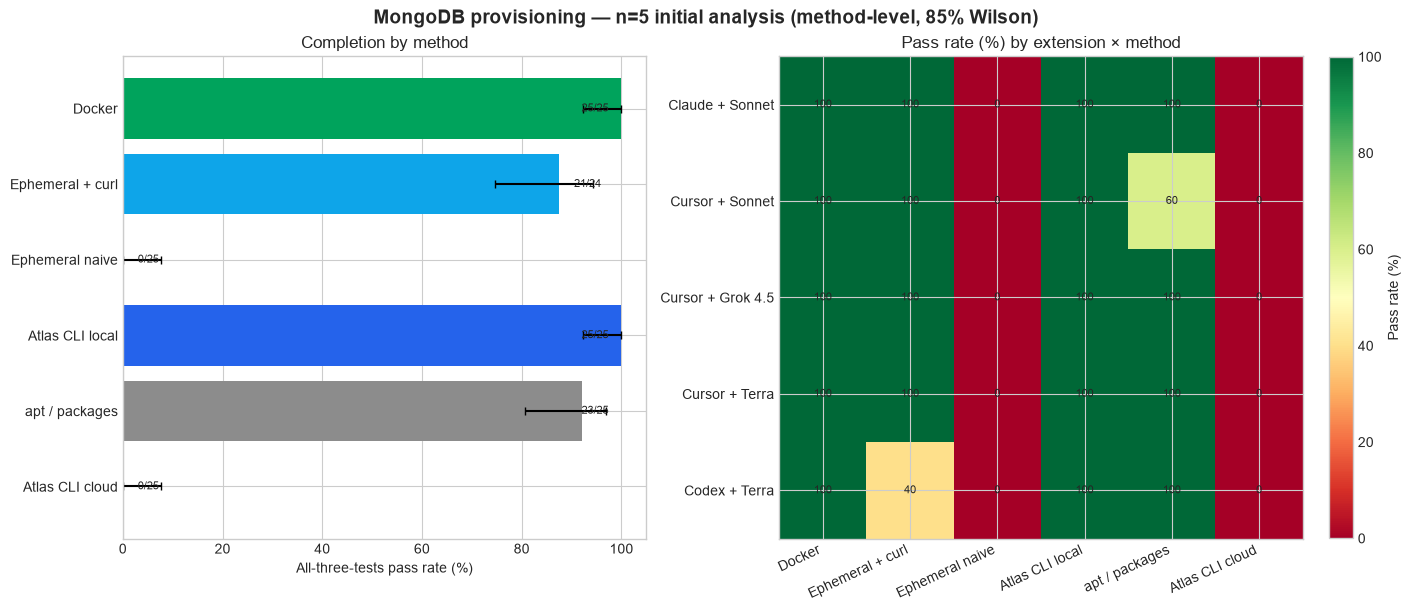

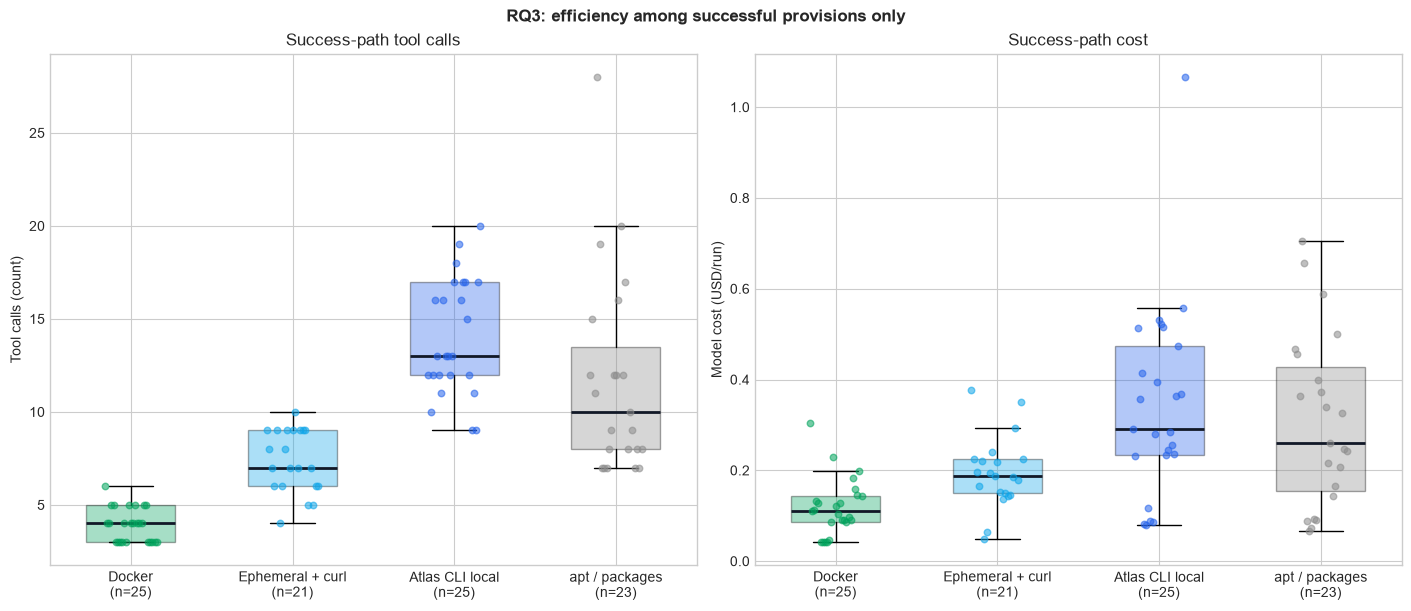

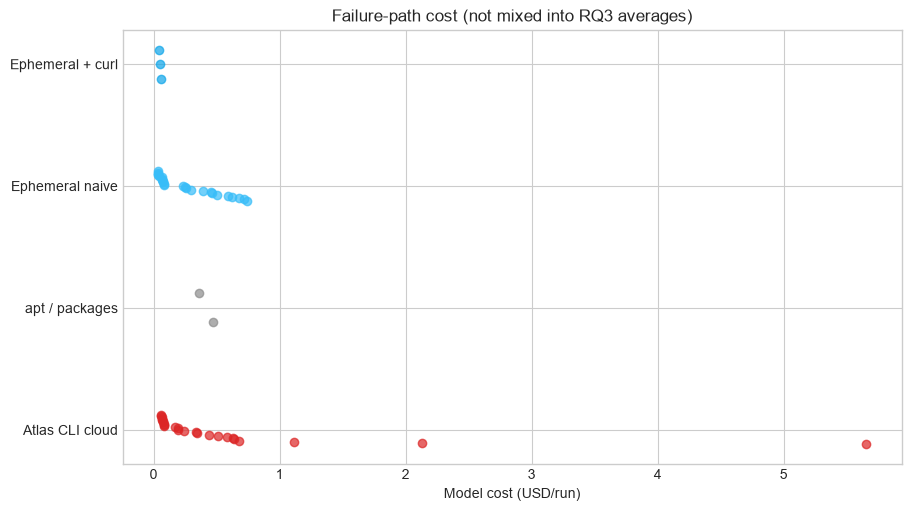

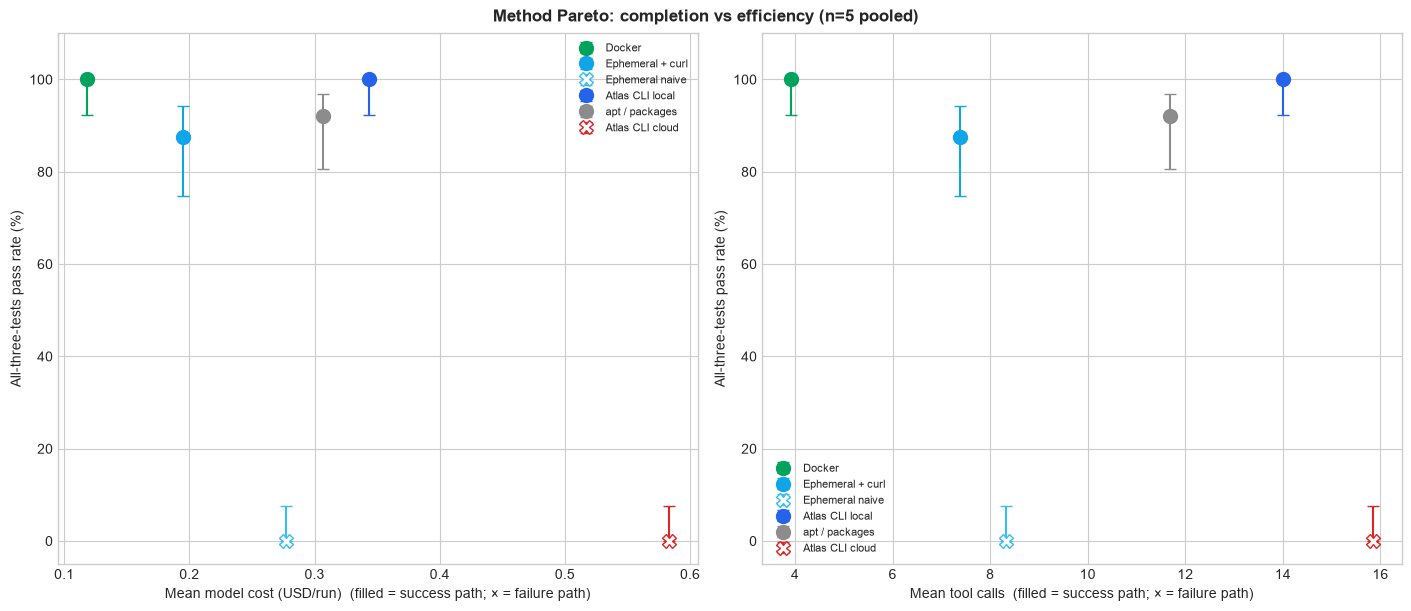

In [11]:
if not READY_GRADED or method_summary.empty:
    print("Waiting for graded runs.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    fig.suptitle(
        "MongoDB provisioning — n=5 initial analysis (method-level, 85% Wilson)",
        fontsize=14,
        fontweight="bold",
    )
    y = np.arange(len(METHOD_ORDER))
    rates = method_summary.set_index("method").reindex(METHOD_ORDER)
    axes[0].barh(
        y,
        rates["pass_rate_pct"],
        color=[COLORS[m] for m in METHOD_ORDER],
        xerr=[
            (rates["pass_rate"] - rates["pass_rate_lo"]) * 100,
            (rates["pass_rate_hi"] - rates["pass_rate"]) * 100,
        ],
        capsize=3,
    )
    axes[0].set_yticks(y, [DISPLAY_NAMES[m] for m in METHOD_ORDER])
    axes[0].invert_yaxis()
    axes[0].set_xlim(0, 105)
    axes[0].set_xlabel("All-three-tests pass rate (%)")
    axes[0].set_title("Completion by method")
    for yi, method in enumerate(METHOD_ORDER):
        row = rates.loc[method]
        axes[0].text(
            min(row.pass_rate_pct + 3, 92),
            yi,
            f"{int(row.all_tests_passed)}/{int(row.runs)}",
            va="center",
            fontsize=8,
        )

    pass_pivot = (
        GRADED.pivot_table(
            index="extension",
            columns="method",
            values="passed",
            aggfunc="mean",
            observed=True,
        )
        .reindex(index=EXTENSION_ORDER, columns=METHOD_ORDER)
        * 100
    )
    image = axes[1].imshow(pass_pivot.to_numpy(dtype=float), cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    axes[1].set_xticks(
        np.arange(len(METHOD_ORDER)),
        [DISPLAY_NAMES[m] for m in METHOD_ORDER],
        rotation=25,
        ha="right",
    )
    axes[1].set_yticks(
        np.arange(len(EXTENSION_ORDER)),
        [DISPLAY_NAMES[e] for e in EXTENSION_ORDER],
    )
    for i, extension in enumerate(EXTENSION_ORDER):
        for j, method in enumerate(METHOD_ORDER):
            value = pass_pivot.loc[extension, method]
            text = "—" if pd.isna(value) else f"{value:.0f}"
            axes[1].text(j, i, text, ha="center", va="center", fontsize=8)
    axes[1].set_title("Pass rate (%) by extension × method")
    fig.colorbar(image, ax=axes[1], fraction=0.046, label="Pass rate (%)")
    plt.show()

    # Success-path tool calls and cost by method
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    success_methods = [m for m in METHOD_ORDER if m in set(SUCCESS["method"])]
    for ax, metric, xlabel, title in [
        (
            axes[0],
            "tool_calls_total",
            "Tool calls (count)",
            "Success-path tool calls",
        ),
        (axes[1], "cost_usd", "Model cost (USD/run)", "Success-path cost"),
    ]:
        distributions = [
            SUCCESS.loc[SUCCESS["method"].eq(method), metric].dropna().to_numpy(dtype=float)
            for method in success_methods
        ]
        positions = np.arange(1, len(success_methods) + 1)
        boxes = ax.boxplot(
            distributions,
            positions=positions,
            widths=0.55,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "#111827", "linewidth": 2},
        )
        for patch, method in zip(boxes["boxes"], success_methods):
            patch.set_facecolor(COLORS[method])
            patch.set_alpha(0.35)
        for position, method, values in zip(positions, success_methods, distributions):
            jitter = np.linspace(-0.16, 0.16, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(position + jitter, values, color=COLORS[method], alpha=0.55, s=22, zorder=3)
        ax.set_xticks(
            positions,
            [f"{DISPLAY_NAMES[m]}\n(n={len(v)})" for m, v in zip(success_methods, distributions)],
        )
        ax.set_ylabel(xlabel)
        ax.set_title(title)
    fig.suptitle("RQ3: efficiency among successful provisions only", fontweight="bold")
    plt.show()

    # Failure-path cost (Cursor grind on cloud is the tail)
    if not FAILURE.empty:
        fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
        fail_methods = [m for m in METHOD_ORDER if m in set(FAILURE["method"])]
        y = np.arange(len(fail_methods))
        for yi, method in enumerate(fail_methods):
            subset = FAILURE[FAILURE["method"].eq(method)].sort_values("cost_usd")
            jitter = np.linspace(-0.12, 0.12, len(subset)) if len(subset) > 1 else np.array([0.0])
            ax.scatter(
                subset["cost_usd"],
                yi + jitter,
                color=COLORS[method],
                alpha=0.7,
                s=36,
            )
        ax.set_yticks(y, [DISPLAY_NAMES[m] for m in fail_methods])
        ax.invert_yaxis()
        ax.set_xlabel("Model cost (USD/run)")
        ax.set_title("Failure-path cost (not mixed into RQ3 averages)")
        plt.show()

    # Pareto: pass rate vs cost / tool calls
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    fig.suptitle("Method Pareto: completion vs efficiency (n=5 pooled)", fontweight="bold")
    for ax, x_col, x_label in [
        (axes[0], "cost_mean", "Mean model cost (USD/run)"),
        (axes[1], "tools_mean", "Mean tool calls"),
    ]:
        for method in METHOD_ORDER:
            rate_row = method_summary.set_index("method").loc[method]
            if rate_row.runs == 0:
                continue
            y_rate = rate_row.pass_rate * 100
            yerr = np.array(
                [
                    [y_rate - rate_row.pass_rate_lo * 100],
                    [rate_row.pass_rate_hi * 100 - y_rate],
                ]
            )
            metric_col = "cost_mean" if x_col == "cost_mean" else "tools_mean"
            if rate_row.all_tests_passed > 0:
                x = float(SUCCESS_EFF.set_index("method").loc[method, metric_col])
                marker = "o"
            else:
                fail_row = FAIL_EFF.set_index("method")
                if method not in fail_row.index:
                    continue
                x = float(fail_row.loc[method, metric_col])
                marker = "X"
            ax.errorbar(
                x,
                y_rate,
                yerr=yerr,
                fmt=marker,
                color=COLORS[method],
                markerfacecolor=COLORS[method] if marker == "o" else "white",
                markeredgecolor=COLORS[method],
                markersize=10,
                capsize=4,
                label=DISPLAY_NAMES[method],
            )
        ax.set_xlabel(x_label + "  (filled = success path; × = failure path)")
        ax.set_ylabel("All-three-tests pass rate (%)")
        ax.set_ylim(-5, 110)
        ax.legend(frameon=False, fontsize=8, loc="best")
    plt.show()


## Cheat / substitution

`method-constraint` fail after uri+connection pass is the design's
goal-substitution tail (a working local URI counted as success if we only
pinged). Tool-call booleans are payload-substring flags, not decoded
credentials.


In [12]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    cloud_like = GRADED[GRADED["method"].isin(CLOUD_BOUND)]
    display(
        cloud_like.groupby(["method", "extension"], observed=True)
        .agg(
            n=("run_id", "size"),
            uri=("uri-reported", "sum"),
            conn=("connection-verified-in-agent", "sum"),
            method_ok=("method-constraint", "sum"),
            uri_and_conn=("uri_and_connection", "sum"),
            substitution=("substitution", "sum"),
            all3=("passed", "sum"),
        )
        .reset_index()
        .assign(
            method_label=lambda f: f["method"].map(DISPLAY_NAMES),
            extension_label=lambda f: f["extension"].map(DISPLAY_NAMES),
        )[
            [
                "method_label",
                "extension_label",
                "n",
                "uri",
                "conn",
                "method_ok",
                "uri_and_conn",
                "substitution",
                "all3",
            ]
        ]
    )
    print(
        "Substitution (uri+connection pass, method-constraint fail): "
        f"{int(GRADED['substitution'].sum())} / {len(GRADED)}"
    )
    print(
        "Atlas CLI cloud hosted success (all three tests): "
        f"{int(GRADED.loc[GRADED['method'].eq('atlas-cli-cloud'), 'passed'].sum())} / "
        f"{int((GRADED['method'] == 'atlas-cli-cloud').sum())}"
    )


,method_label,extension_label,n,uri,conn,method_ok,uri_and_conn,substitution,all3
0,Ephemeral + curl,Claude + Sonnet,5,5,5,5,5,0,5
1,Ephemeral + curl,Cursor + Sonnet,4,4,4,4,4,0,4
2,Ephemeral + curl,Cursor + Grok 4.5,5,5,5,5,5,0,5
3,Ephemeral + curl,Cursor + Terra,5,5,5,5,5,0,5
4,Ephemeral + curl,Codex + Terra,5,5,2,5,2,0,2
5,Ephemeral naive,Claude + Sonnet,5,1,1,0,1,1,0
6,Ephemeral naive,Cursor + Sonnet,5,5,4,0,4,4,0
7,Ephemeral naive,Cursor + Grok 4.5,5,5,5,0,5,5,0
8,Ephemeral naive,Cursor + Terra,5,0,0,0,0,0,0
9,Ephemeral naive,Codex + Terra,5,0,0,0,0,0,0


Substitution (uri+connection pass, method-constraint fail): 12 / 149
Atlas CLI cloud hosted success (all three tests): 0 / 25


In [13]:
mismatch_sql = f"""
SELECT
    resolved_extend_id,
    prompt_id,
    countDistinct(run_id) AS runs,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'docker run') > 0
        OR positionCaseInsensitive(payload, 'docker compose') > 0
    ) AS docker_run,
    countDistinctIf(run_id, positionCaseInsensitive(payload, 'atlas deployments') > 0) AS atlas_deployments,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'atlas clusters') > 0
        OR positionCaseInsensitive(payload, 'atlas cluster') > 0
    ) AS atlas_clusters,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'ephemeralClusters') > 0
    ) AS ephemeral_api,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'apt-get') > 0
        OR positionCaseInsensitive(payload, 'apt install') > 0
    ) AS apt,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'atlas auth') > 0
        OR positionCaseInsensitive(payload, 'auth login') > 0
    ) AS atlas_auth,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'mongodb.net') > 0
        OR positionCaseInsensitive(payload, 'mongodb-dev.net') > 0
    ) AS mentions_atlas_host
FROM events
WHERE run_request_id IN ({REQUEST_SQL})
  AND kind = 'tool_call'
GROUP BY resolved_extend_id, prompt_id
ORDER BY resolved_extend_id, prompt_id
"""

if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    mismatch = assign_extension(_with_method_column(ax_query(mismatch_sql)))
    bool_cols = [
        "runs",
        "docker_run",
        "atlas_deployments",
        "atlas_clusters",
        "ephemeral_api",
        "apt",
        "atlas_auth",
        "mentions_atlas_host",
    ]
    for column in bool_cols:
        mismatch[column] = pd.to_numeric(mismatch[column])
    mismatch["method"] = pd.Categorical(mismatch["method"], categories=METHOD_ORDER, ordered=True)
    mismatch["extension_label"] = mismatch["extension"].map(DISPLAY_NAMES)
    mismatch["method_label"] = mismatch["method"].map(DISPLAY_NAMES)
    display(mismatch[["extension_label", "method_label", *bool_cols]])


,extension_label,method_label,runs,docker_run,atlas_deployments,atlas_clusters,ephemeral_api,apt,atlas_auth,mentions_atlas_host
0,Claude + Sonnet,Atlas CLI cloud,5,0,0,0,0,0,3,0
1,Claude + Sonnet,Atlas CLI local,5,2,5,0,0,3,0,0
2,Claude + Sonnet,Ephemeral + curl,5,0,0,4,5,0,0,5
3,Claude + Sonnet,Ephemeral naive,5,0,1,0,0,0,0,0
4,Claude + Sonnet,Docker,5,5,0,0,0,0,0,0
5,Claude + Sonnet,apt / packages,5,0,0,0,0,5,0,0
6,Codex + Terra,Atlas CLI cloud,5,0,0,0,0,3,4,0
7,Codex + Terra,Atlas CLI local,5,0,5,3,0,0,1,0
8,Codex + Terra,Ephemeral + curl,5,0,0,0,5,0,0,5
9,Codex + Terra,Ephemeral naive,5,0,0,0,0,0,0,0


## What we drop before the larger run

n=5 already answered two recipes well enough that **more repeats will not
teach us more:**

1. **Naive ephemeral Atlas** (no curl in the prompt): 0/25 real ephemeral
   clusters. Agents do not discover the new API. Extra trials would
   mostly re-count Cursor standing up a local database instead.
2. **Atlas CLI to real cloud:** 0/25 hosted clusters. There is no Atlas
   login in the sandbox. Extra trials would re-count the login wall and
   Cursor sometimes falling back to local.

Those two stay in the tables above as n=5 findings. They are **not** in
the scale matrix.

**Scale recipes (4):** Docker, ephemeral Atlas with curl, Atlas CLI
local, apt.

**Agents (5):** still all of them. None failed Docker. Claude vs Cursor
on Sonnet, and Codex vs Cursor on Terra, still look different on the
recipes we are keeping (apt misses; Codex skipping the ephemeral ping).

The numeric checks below compare agents **only on the four recipes we
will keep running.**


In [14]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    print("n=5 recipes we will not run again:")
    dropped = GRADED[GRADED["method"].isin(DROPPED_FROM_SCALE)]
    dropped_summary = (
        dropped.groupby("method", observed=True)
        .agg(n=("run_id", "size"), passed=("passed", "sum"), subst=("substitution", "sum"))
        .reindex(DROPPED_FROM_SCALE)
        .reset_index()
    )
    dropped_summary["method_label"] = dropped_summary["method"].map(DISPLAY_NAMES)
    display(dropped_summary[["method_label", "n", "passed", "subst"]])

    scale_runs = GRADED[GRADED["method"].isin(SCALE_METHODS)].copy()
    print("Scale recipes (this n=5, kept for later):")
    kn = (
        scale_runs.pivot_table(
            index="extension",
            columns="method",
            values="passed",
            aggfunc=["sum", "count"],
            observed=True,
        )
    )
    k = kn["sum"].reindex(index=EXTENSION_ORDER, columns=SCALE_METHODS)
    n = kn["count"].reindex(index=EXTENSION_ORDER, columns=SCALE_METHODS)
    kn_fmt = k.fillna(0).astype(int).astype(str) + "/" + n.fillna(0).astype(int).astype(str)
    kn_fmt.index = [DISPLAY_NAMES.get(i, i) for i in kn_fmt.index]
    kn_fmt.columns = [DISPLAY_NAMES.get(c, c) for c in kn_fmt.columns]
    display(kn_fmt)
    print(
        f"Kept-recipe success: {int(scale_runs['passed'].sum())}/{len(scale_runs)} "
        f"({scale_runs['passed'].mean():.1%})"
    )

    print("Did every agent succeed on Docker (the easy recipe)?")
    docker_by_ext = (
        GRADED[GRADED["method"].eq("docker")]
        .groupby("extension", observed=True)["passed"]
        .agg(k="sum", n="count")
        .reindex(EXTENSION_ORDER)
        .dropna(how="all")
    )
    docker_by_ext["all_passed"] = docker_by_ext["k"].eq(docker_by_ext["n"]) & docker_by_ext["n"].ge(5)
    display(docker_by_ext)
    if docker_by_ext["all_passed"].all():
        print("Yes. No agent combo is dead on arrival; keep all five for scale.")
    else:
        print("Failed Docker:", list(docker_by_ext.index[~docker_by_ext["all_passed"]]))

    rows = []
    for left, right, label in HARNESS_PAIRS:
        for method in SCALE_METHODS:
            a = CELL[(CELL["extension"] == left) & (CELL["method"] == method)]
            b = CELL[(CELL["extension"] == right) & (CELL["method"] == method)]
            if a.empty or b.empty:
                rows.append({"pair": label, "method": DISPLAY_NAMES[method], "note": "missing cell"})
                continue
            a, b = a.iloc[0], b.iloc[0]
            overlap = a.pass_rate_hi >= b.pass_rate_lo and b.pass_rate_hi >= a.pass_rate_lo
            left_all = GRADED[(GRADED["extension"] == left) & (GRADED["method"] == method)]
            right_all = GRADED[(GRADED["extension"] == right) & (GRADED["method"] == method)]
            cost_ratio = (
                left_all["cost_usd"].mean() / right_all["cost_usd"].mean()
                if right_all["cost_usd"].mean()
                else np.nan
            )
            tool_ratio = (
                left_all["tool_calls_total"].mean() / right_all["tool_calls_total"].mean()
                if right_all["tool_calls_total"].mean()
                else np.nan
            )
            rows.append(
                {
                    "pair": label,
                    "method": DISPLAY_NAMES[method],
                    "left": DISPLAY_NAMES[left],
                    "right": DISPLAY_NAMES[right],
                    "left_n": int(a.runs),
                    "right_n": int(b.runs),
                    "left_pass_pct": a.pass_rate_pct,
                    "right_pass_pct": b.pass_rate_pct,
                    "ci_overlap": overlap,
                    "pass_pp_diff": (a.pass_rate - b.pass_rate) * 100,
                    "cost_ratio_left_over_right": cost_ratio,
                    "tools_ratio_left_over_right": tool_ratio,
                }
            )
    prune = pd.DataFrame(rows)
    print("Same-model agent pairs, on the four recipes we will keep:")
    display(prune.round(3))

    print("Should we drop one agent that uses the same model as another?")
    for left, right, label in HARNESS_PAIRS:
        subset = prune[prune["pair"] == label]
        if subset.empty or "ci_overlap" not in subset:
            print(f"- {label}: not enough cells")
            continue
        complete_cells = (subset[["left_n", "right_n"]] >= 4).all().all()
        close_completion = subset["pass_pp_diff"].abs().le(10).all()
        comparable_cost = subset["cost_ratio_left_over_right"].between(1 / 1.15, 1.15).all()
        look_the_same = complete_cells and close_completion and comparable_cost
        if look_the_same:
            left_cost = scale_runs.loc[scale_runs["extension"] == left, "cost_usd"].mean()
            right_cost = scale_runs.loc[scale_runs["extension"] == right, "cost_usd"].mean()
            cheaper = left if left_cost <= right_cost else right
            drop = right if cheaper == left else left
            print(
                f"- {label}: they look close on the kept recipes. "
                f"Keep {DISPLAY_NAMES[cheaper]}; consider dropping {DISPLAY_NAMES[drop]}."
            )
        else:
            reasons = []
            if not complete_cells:
                reasons.append("a cell has fewer than 4 finished runs")
            if not close_completion:
                reasons.append("success rate differs by more than 10 points on at least one recipe")
            if not comparable_cost:
                reasons.append("mean cost differs by more than 15% on at least one recipe")
            print(f"- {label}: keep both (" + "; ".join(reasons) + ").")


n=5 recipes we will not run again:


,method_label,n,passed,subst
0,Ephemeral naive,25,0,10
1,Atlas CLI cloud,25,0,2


Scale recipes (this n=5, kept for later):


,Docker,Ephemeral + curl,Atlas CLI local,apt / packages
Claude + Sonnet,5/5,5/5,5/5,5/5
Cursor + Sonnet,5/5,4/4,5/5,3/5
Cursor + Grok 4.5,5/5,5/5,5/5,5/5
Cursor + Terra,5/5,5/5,5/5,5/5
Codex + Terra,5/5,2/5,5/5,5/5


Kept-recipe success: 94/99 (94.9%)
Did every agent succeed on Docker (the easy recipe)?


,k,n,all_passed
extension,,,
claude-sonnet,5,5,True
cursor-sonnet,5,5,True
cursor-grok,5,5,True
cursor-terra,5,5,True
codex-terra,5,5,True


Yes. No agent combo is dead on arrival; keep all five for scale.
Same-model agent pairs, on the four recipes we will keep:


,pair,method,left,right,left_n,right_n,left_pass_pct,right_pass_pct,ci_overlap,pass_pp_diff,cost_ratio_left_over_right,tools_ratio_left_over_right
0,Sonnet across Claude vs Cursor,Docker,Claude + Sonnet,Cursor + Sonnet,5,5,100.0,100.0,True,0.0,1.179,1.143
1,Sonnet across Claude vs Cursor,Ephemeral + curl,Claude + Sonnet,Cursor + Sonnet,5,4,100.0,100.0,True,0.0,1.126,0.945
2,Sonnet across Claude vs Cursor,Atlas CLI local,Claude + Sonnet,Cursor + Sonnet,5,5,100.0,100.0,True,0.0,0.806,0.797
3,Sonnet across Claude vs Cursor,apt / packages,Claude + Sonnet,Cursor + Sonnet,5,5,100.0,60.0,True,40.0,1.207,1.269
4,Terra across Codex vs Cursor,Docker,Codex + Terra,Cursor + Terra,5,5,100.0,100.0,True,0.0,0.472,0.727
5,Terra across Codex vs Cursor,Ephemeral + curl,Codex + Terra,Cursor + Terra,5,5,40.0,100.0,False,-60.0,0.363,0.545
6,Terra across Codex vs Cursor,Atlas CLI local,Codex + Terra,Cursor + Terra,5,5,100.0,100.0,True,0.0,0.359,0.844
7,Terra across Codex vs Cursor,apt / packages,Codex + Terra,Cursor + Terra,5,5,100.0,100.0,True,0.0,0.364,0.567


Should we drop one agent that uses the same model as another?
- Sonnet across Claude vs Cursor: keep both (success rate differs by more than 10 points on at least one recipe; mean cost differs by more than 15% on at least one recipe).
- Terra across Codex vs Cursor: keep both (success rate differs by more than 10 points on at least one recipe; mean cost differs by more than 15% on at least one recipe).


## How many more runs we need

n=5 was to decide what to drop. The larger run is to compare the **four
kept recipes** with more confidence. We want roughly 90–130 trials per
recipe (all five agents added together) to see a 10-point gap in success
rate. Twenty extra repeats of each agent × recipe cell is still too small
to rank a single agent; the useful comparison is recipe vs recipe.


In [15]:
def n_for_margin(p, margin, z=Z_85):
    if margin <= 0:
        return np.inf
    return int(np.ceil((z**2 * p * (1 - p)) / margin**2))


def n_two_proportion(p1, p2, z_alpha=Z_85, z_power=0.8416):
    delta = abs(p1 - p2)
    if delta == 0:
        return np.inf
    return int(
        np.ceil(
            ((z_alpha + z_power) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2))) / delta**2
        )
    )


if not READY_GRADED:
    p_hat = 0.8
    print("Waiting for graded runs; using p=0.8 for the sample-size table.")
else:
    scale_runs = GRADED[GRADED["method"].isin(SCALE_METHODS)]
    p_hat = float(scale_runs["passed"].mean())
    print(
        f"Success rate on the four recipes we will keep: "
        f"{int(scale_runs['passed'].sum())}/{len(scale_runs)} = {p_hat:.1%}"
    )

ci_width = pd.DataFrame(
    {
        "trials_per_recipe": [25, 50, 100, 125],
        "uncertainty_band_pp": [
            100 * Z_85 * np.sqrt(p_hat * (1 - p_hat) / n) for n in (25, 50, 100, 125)
        ],
        "note": [
            "this n=5 (5 agents × 5 repeats)",
            "halfway",
            "near a 10-point gap",
            "n=5 + 20 extra, five agents (scale plan)",
        ],
    }
)
power = pd.DataFrame(
    [
        {"question": "Tell 70% from 90% apart", "trials_per_recipe": n_two_proportion(0.70, 0.90)},
        {"question": "Tell 80% from 90% apart", "trials_per_recipe": n_two_proportion(0.80, 0.90)},
        {"question": "Tell 90% from 100% apart", "trials_per_recipe": n_two_proportion(0.90, 1.00)},
        {"question": "±10 point band around 90% success", "trials_per_recipe": n_for_margin(0.9, 0.10)},
        {"question": "±10 point band around 95% success", "trials_per_recipe": n_for_margin(0.95, 0.10)},
    ]
)
display(ci_width.round(1))
display(power)

if READY_GRADED:
    n_ext = GRADED["extension"].nunique()
    n_scale_methods = len(SCALE_METHODS)
    print(
        f"Scale plan: {n_ext} agents × {n_scale_methods} recipes × 20 extra repeats "
        f"= {n_ext * n_scale_methods * 20} new trials."
    )
    print(
        f"Per recipe after combining n=5 + 20 extra: about {n_ext * 25} trials "
        "(enough to compare recipes, not enough to crown a single agent)."
    )


Success rate on the four recipes we will keep: 94/99 = 94.9%


,trials_per_recipe,uncertainty_band_pp,note
0,25,6.3,this n=5 (5 agents × 5 repeats)
1,50,4.5,halfway
2,100,3.2,near a 10-point gap
3,125,2.8,"n=5 + 20 extra, five agents (scale plan)"


,question,trials_per_recipe
0,Tell 70% from 90% apart,40
1,Tell 80% from 90% apart,131
2,Tell 90% from 100% apart,47
3,±10 point band around 90% success,19
4,±10 point band around 95% success,10


Scale plan: 5 agents × 4 recipes × 20 extra repeats = 400 new trials.
Per recipe after combining n=5 + 20 extra: about 125 trials (enough to compare recipes, not enough to crown a single agent).


## Cost of this run and scale estimates


In [16]:
if not READY_GRADED:
    print("Waiting for graded runs.")
else:
    by_ext = (
        GRADED.groupby("extension", observed=True)
        .agg(n=("run_id", "size"), mean_usd=("cost_usd", "mean"), total_usd=("cost_usd", "sum"))
        .reindex(EXTENSION_ORDER)
    )
    by_method = (
        GRADED.groupby("method", observed=True)
        .agg(
            n=("run_id", "size"),
            pass_rate=("passed", "mean"),
            mean_usd=("cost_usd", "mean"),
            mean_s=("runtime_s", "mean"),
            mean_tools=("tool_calls_total", "mean"),
        )
        .reindex(METHOD_ORDER)
    )
    n5_total = float(GRADED["cost_usd"].sum())
    scale_runs = GRADED[GRADED["method"].isin(SCALE_METHODS)]
    dropped_runs = GRADED[GRADED["method"].isin(DROPPED_FROM_SCALE)]
    per_trial_scale = float(scale_runs["cost_usd"].sum() / max(len(scale_runs), 1))
    n_ext = int(GRADED["extension"].nunique())
    n_scale_methods = len(SCALE_METHODS)
    additional_20 = n_ext * n_scale_methods * 20 * per_trial_scale
    drop_cursor_sonnet = (n_ext - 1) * n_scale_methods * 20 * per_trial_scale

    scale = pd.Series(
        {
            "n5_all_six_recipes_usd": n5_total,
            "n5_four_kept_recipes_usd": float(scale_runs["cost_usd"].sum()),
            "n5_two_dropped_recipes_usd": float(dropped_runs["cost_usd"].sum()),
            "mean_usd_per_trial_kept_recipes": per_trial_scale,
            "agents": n_ext,
            "scale_recipes": n_scale_methods,
            "n20_extra_trials": n_ext * n_scale_methods * 20,
            "n20_extra_usd": additional_20,
            "n20_extra_usd_if_drop_cursor_sonnet": drop_cursor_sonnet,
            "n5_plus_n20_usd": n5_total + additional_20,
        }
    )
    print("By agent (all six n=5 recipes)")
    display(by_ext.round(4))
    print("By recipe (all six; the last two will not be run again)")
    display(by_method.round(3))
    print(
        "Next-run cost uses the average $ of the four recipes we will keep "
        f"(${per_trial_scale:.2f}/trial), not the cloud/naive failures."
    )
    display(scale.to_frame("value").round(2))


By agent (all six n=5 recipes)


,n,mean_usd,total_usd
extension,,,
claude-sonnet,30,0.2733,8.1988
cursor-sonnet,29,0.3519,10.2056
cursor-grok,30,0.6661,19.9827
cursor-terra,30,0.1648,4.9440
codex-terra,30,0.0619,1.8570


By recipe (all six; the last two will not be run again)


,n,pass_rate,mean_usd,mean_s,mean_tools
method,,,,,
docker,25,1.000,0.118,42.998,3.920
atlas-ephemeral-curl,24,0.875,0.177,58.766,7.042
atlas-ephemeral-naive,25,0.000,0.277,69.564,8.320
atlas-cli-local,25,1.000,0.344,117.953,14.000
local-package-manager,25,0.920,0.316,90.443,11.840
atlas-cli-cloud,25,0.000,0.583,194.623,15.840


Next-run cost uses the average $ of the four recipes we will keep ($0.24/trial), not the cloud/naive failures.


,value
n5_all_six_recipes_usd,45.19
n5_four_kept_recipes_usd,23.70
n5_two_dropped_recipes_usd,21.49
mean_usd_per_trial_kept_recipes,0.24
agents,5.00
scale_recipes,4.00
n20_extra_trials,400.00
n20_extra_usd,95.75
n20_extra_usd_if_drop_cursor_sonnet,76.60
n5_plus_n20_usd,140.93


## Interpretation

Computed on `01M0K02HXMWQWP59QE4DE3NMA4` plus retry
`01M0K11JZAPN2N1Y5ZJFFRYYAE`. **149 graded trials** (2 Cursor × Sonnet ×
ephemeral-curl rows died because Cursor rejected the model id
`claude-sonnet-5`; the retry filled one of those slots, so that cell is
4/4 finished rather than 5). Cost on graded rows ≈ **$45.19** (mean
≈ $0.30). The scorers did not crash.

### What counted as success

A run succeeds only if the agent reported a connection string, showed a
real connection, and used the recipe we asked for. Codex ephemeral-curl
misses are “created a cluster but never pinged it,” not a broken scorer.

### Recipes we will keep (Docker, curl-ephemeral, Atlas CLI local, apt)

On these four, success was **94/99 ≈ 94.9%** (range about 91–97%). That
is strong, but it is not proof of “always above 95%.”

- Docker 25/25 and Atlas CLI local 25/25: same success rate for practical
  purposes. Local takes about 3× the steps and dollars of Docker.
- apt 23/25: two Cursor × Sonnet runs never proved a connection. Too
  little data to say apt is worse than Docker on success; it is clearly
  slower and more expensive when it works.
- Ephemeral with curl 21/24: worse than Docker by enough to notice. The
  hole is Codex skipping the ping (URI present, hosted host present,
  no connection check).

Among successes, Docker is cheapest and fewest steps (~3.9 tool calls,
~$0.12). Curl is next but still clearly more work (~7.4 calls, ~$0.20).
apt and Atlas CLI local are roughly 3× Docker on steps and 2.5–3× on
cost. Codex always reports “1 turn”; that is the harness counting, not
a one-step job. Prefer tool calls and dollars when comparing agents.

### Recipes we will not run again

**Naive ephemeral (no curl):** 0/25 real ephemeral clusters. Nobody
called the new API. Cursor often stood up a local MongoDB and reported
that URI (Grok 5/5, Cursor Sonnet 4/5, Claude 1/5). Codex and Cursor ×
Terra failed without substituting. More repeats would re-measure that
docs/discovery miss, not a close success rate.

**Atlas CLI to real cloud:** 0/25 hosted clusters. No browser login in
the sandbox. Cursor × Grok twice fell back to a local Atlas deployment.
Cursor × Sonnet spent many minutes grinding. More repeats would
re-measure the login wall.

apt did **not** secretly use Docker (apt on 25/25, `docker run` on
0/25). Atlas CLI local using Docker under the hood is expected
(`atlas deployments` starts a container).

### Agents

Keep all five. All are 5/5 on Docker.

- Claude × Sonnet vs Cursor × Sonnet are not copies: apt is 5/5 vs 3/5,
  and Cursor had the model-id errors. Keep both.
- Codex × Terra vs Cursor × Terra are not copies: ephemeral-with-curl is
  2/5 vs 5/5 (Codex ping skip). Codex is cheap; Cursor actually finishes
  ephemeral. Keep both.
- Cursor × Grok stays. It still completes the four kept recipes; we are
  just not paying extra to watch it substitute on cloud/naive again.

Before the next run, point Cursor’s Sonnet at a model id Cursor accepts
(`claude-sonnet-5-high` or `claude-4.5-sonnet`) so those cells do not
randomly error.

### Next run

**4 recipes × 5 agents × 20 extra repeats = 400 new trials.** Carry the
n=5 rows on those four recipes forward. That is about 125 trials per
recipe, which is the sample we wanted to compare recipes. Do not treat
a single agent × recipe cell as a final ranking.

This n=5 already spent **~$45** (including the two recipes we are
dropping). The extra 400 trials, priced at the average of the four
kept recipes (~$0.24), is about **$95**. Combined ~$140 before
contingency. Cursor × Grok is still the expensive agent on the kept
recipes; keep it unless spend must fall.
